In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt
import scipy.stats as stats_func

import seaborn as sns

In [2]:
def compute_high_movement_cond(episodes, running_speed_threshold):
    """
    Calculates wether the episodes are active or resting.

    Args:
        episodes (array of Episode): (Episode#, ROI#, dFoF_values (0.5ms sampling rate)).
        running_speed_threshold (float): The threshold to discriminate resting state and active state.

    Returns:
        np.array : HMcond is True when active and false when resting
    """
 
    if running_speed_threshold is not None:
        run_speed_bool = (episodes.running_speed > running_speed_threshold)  
        
        HMcond = []
        prop_thresh = 0.75*len(run_speed_bool[0]) #if 75% values during stimulation are above 0.1, then the animal is "active"
        
        for i in range(len(run_speed_bool)):
            if np.sum(run_speed_bool[i])> prop_thresh:  
                HMcond.append(True)
            else: 
                HMcond.append(False)
                
        HMcond = np.array(HMcond) 

    else: 
        print("running_speed_threshold not given")
    
    return HMcond

In [3]:
def get_stats(all_diffs_act, all_diffs_rest):
    
    t_stats, p_val = stats_func.ttest_ind(all_diffs_act, all_diffs_rest, nan_policy='omit')
    significance = 'ns'                  
    if p_val==np.nan or p_val>0.05:
        significance = 'ns'  # Default is "not significant"
    elif p_val < 0.001:
        significance = '***'
    elif p_val < 0.01:
        significance = '**'
    elif p_val < 0.05:
        significance = '*'

    return t_stats, p_val, significance

# SST 2024-2025 dataset

In [4]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs_test" [...]
 -> found n=17 datafiles (in 25.5s) 


## Example for 1 file

In [5]:
index = 8
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)

#### Difference across episodes for a specific roi

Text(0.5, 1.0, 'Roi #10')

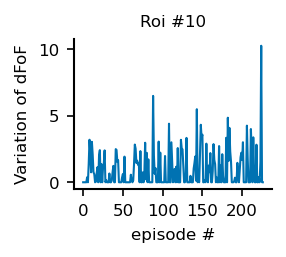

In [6]:
roi = 10
diffs = []
for i in range(len(episodes.dFoF[:,roi,:])):
    ini_val = episodes.dFoF[i,roi,1000]
    max_val = np.max(episodes.dFoF[i,roi,[1000,3000]])
    diff = max_val - ini_val
    diffs.append(diff)

plt.plot(diffs)
plt.xticks(np.arange(0,250,50)) 
plt.xlabel("episode #") 
plt.ylabel("Variation of dFoF")
plt.title(f"Roi #{roi}")

#### Difference across roi (mean of all episodes)

58


Text(0, 0.5, 'Variation of dFoF')

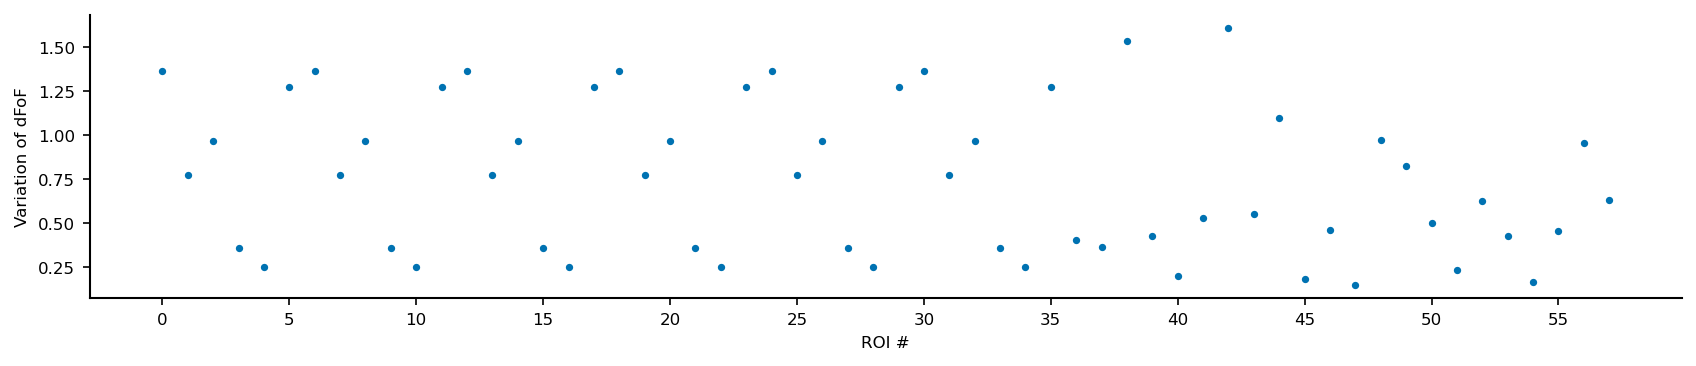

In [7]:
diffs = []
for i in range(len(episodes.dFoF[:,:,:].mean(axis=0))):
    ini_val = episodes.dFoF[:,i,1000].mean(axis=0)
    max_val = np.max(episodes.dFoF[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs.append(diff)

print(len(diffs))

fig, ax = pt.figure(figsize=(3.5, 3))
plt.scatter(np.arange(0, len(diffs),1), diffs)
plt.xticks(np.arange(0,len(diffs),5)) 
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")


#### Differentiate active and resting state

0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.19133151112299007
0.8890903653034798
1.0087481528526527
0.14258887753147487
0.17258346087094245
1.2077494225613892
0.20056901765254498
0.3000349006195957
3.6881203746591082
0.23026580607941938
0.7135061305701829
0.985713149349591
3.219400384607124
1.1317889251124098
1.1195196111836418
0.5870227496149731
0.6027759849564369
0.3380921505555734
0.9150798005367
1.0971380944626627
0.6398296940136028
0.59022956050491

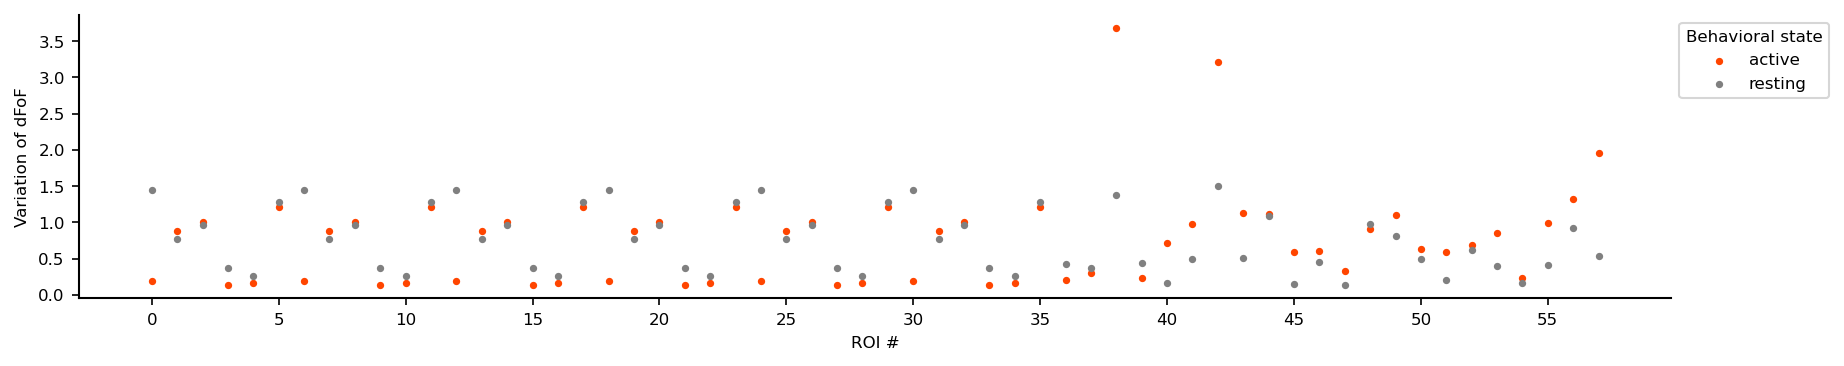

In [8]:
HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)


fig, ax = pt.figure(figsize=(3.5, 3))

#active
episodes_act = episodes.dFoF[HMcond]
diffs_act = []
for i in range(len(episodes_act[:,:,:].mean(axis=0))):
    ini_val = episodes_act[:,i,1000].mean(axis=0)
    max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    print(diff)
    diffs_act.append(diff)

plt.scatter(np.arange(0, len(diffs_act),1), diffs_act, color='orangered', label = 'active')

#rest 
episodes_rest = episodes.dFoF[~HMcond]

diffs_rest = []
n_roi = len(episodes_rest[:,:,:].mean(axis=0))

for roi in range(n_roi):
    ini_val = episodes_rest[:,roi,1000].mean(axis=0)
    max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    print(diff)
    diffs_rest.append(diff)
    

plt.scatter(np.arange(0, len(diffs_rest),1), diffs_rest, color='grey', label="resting")
#plt.set_xlabel("ROI #")
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title = "Behavioral state")
plt.xticks(np.arange(0,len(diffs_rest),5))  

print("episodes active  : ", len(episodes_act))
print("episodes resting : ", len(episodes_rest))
print(f"average for active episodes  : {np.mean(diffs_act):.2f}" )
print(f"average for resting episodes : {np.mean(diffs_rest):.2f}")


For each ROI, the variation of dFoF was plotted diving active and resting episodes (active were averaged together and resting were averaged together). Active episodes seem to be correlated to a bigger variation of dFoF.

## ALL files analysis

In [9]:
episodes_ = []

for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF(verbose=False)
    data.build_running_speed()
    
    episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,  ##important !!
                       verbose=False)
    episodes_.append(episodes)

In [17]:
all_diffs_act = []
all_diffs_rest = []
variations_act = []
variations_rest = []

for i, episodes in enumerate(episodes_):
    
    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
    
    #active
    episodes_act = episodes.dFoF[HMcond]
    episodes_rest = episodes.dFoF[~HMcond]

    minsize_subgroup_episodes = int(0.05*len(episodes.dFoF))#~11, 12  #there is a minimum of 5% of total episodes that has to be present in a subgroup to be able to compare  (can be discussed)!!
    if (len(episodes_act) > minsize_subgroup_episodes) and (len(episodes_rest) > minsize_subgroup_episodes):  
        diffs_act = []
        n_roi = len(episodes_act[:,:,:].mean(axis=0))
        for i in range(n_roi):
            ini_val = episodes_act[:,i,0].mean(axis=0)
            max_val = np.max(episodes_act[:,i,:].mean(axis=0))
            diff = max_val - ini_val
            diffs_act.append(diff)
            all_diffs_act.append(diff)
            
        variations_act.append(np.mean(diffs_act))    

        diffs_rest = []
        n_roi = len(episodes_rest[:,:,:].mean(axis=0))
        for roi in range(n_roi):
            ini_val = episodes_rest[:,roi,0].mean(axis=0)
            max_val = np.max(episodes_rest[:,roi,:].mean(axis=0))
            diff = max_val - ini_val
            diffs_rest.append(diff)
            all_diffs_rest.append(diff)
        variations_rest.append(np.mean(diffs_rest))  


C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_23612\3346469008.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[0][1] )
C:\Users\laura.gonzalez\AppData\Local\Temp\ipykernel_23612\3346469008.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[1][1] )


ALL ROIs for all files 
number of ROIs : 280
active mean : 0.740, resting mean : 0.443
t_stats : 4.542, p_value : 0.000, significance : ***

 Average ROIs for all files
number of files : 8
active mean : 0.654, resting mean : 0.386
t_stats : 1.836, p_value : 0.088, significance : ns


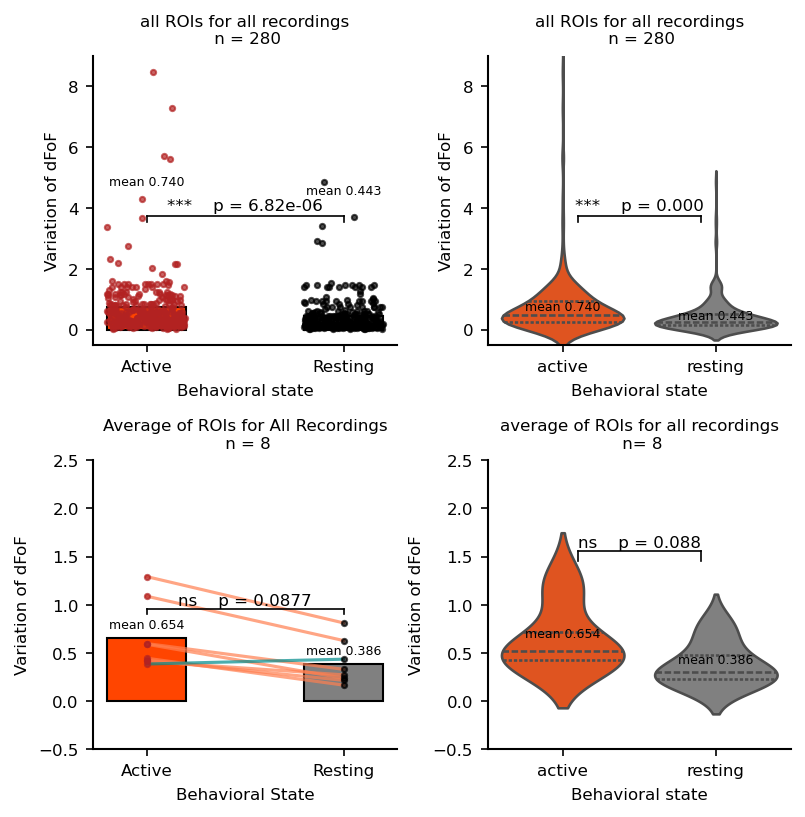

In [18]:
cols = 2  # Number of columns per row
rows = 2  # Compute the required number of rows
#fig, AX = pt.figure(axes=(cols, rows), hspace=2, figsize=(2, 2))
fig, AX = plt.subplots(rows, cols, figsize=(6, 6))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

#############################################################################################################
#barplot all rois for all recordings
bar_width = 0.4
x = np.arange(2)  
means = [np.nanmean(all_diffs_act), np.nanmean(all_diffs_rest)]
AX[0][0].bar(x, means, width=bar_width, color=['orangered', 'grey'], edgecolor='black')
jitter_strength = 0.2  # Adjust for more/less jitter
x_act = np.full_like(all_diffs_act, x[0])
x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(all_diffs_act, x[1])
x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
AX[0][0].scatter(x_act_jitter, all_diffs_act, color='firebrick', zorder=4, label="Active", alpha=0.7)
AX[0][0].scatter(x_rest_jitter, all_diffs_rest, color='black', zorder=4, label="Resting", alpha=0.7)
AX[0][0].set_xticks(x, ['Active', 'Resting'])
AX[0][0].set_xlabel("Behavioral state")
AX[0][0].set_ylabel("Variation of dFoF")
AX[0][0].set_title(f"all ROIs for all recordings\n n = {len(all_diffs_act)}")

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
AX[0][0].plot([x[0], x[1]], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
AX[0][0].plot([x[0], x[0]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][0].plot([x[1], x[1]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][0].text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.3}", ha='center', va='bottom', fontsize=8)
AX[0][0].set_ylim([-0.5,9])

# Annotate each bar with its mean value
for i in range(2):
    AX[0][0].text(i, means[i] + 4, f'mean {means[i]:.3f}', ha='center', fontsize=6)


#############################################################################################################
#violing all rois for all recordings

d = {'active': all_diffs_act, 'resting': all_diffs_rest}
df = pd.DataFrame(data=d)
df_melted = df.melt(var_name="Behavioral state", value_name="Variation of dFoF")
sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[0][1] )

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
AX[0][1].plot([x[0]+0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
AX[0][1].plot([x[0]+0.1, x[0]+0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][1].plot([x[1]-0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][1].text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.3f}", ha='center', va='bottom', fontsize=8)
AX[0][1].set_title(f"all ROIs for all recordings\n n = {len(all_diffs_act)}")
AX[0][1].set_ylim([-0.5,9])

print("ALL ROIs for all files ")
print("number of ROIs :", len(all_diffs_act))
print(f"active mean : {means[0]:.3f}, resting mean : {means[1]:.3f}")
print(f"t_stats : {t_stats:.3f}, p_value : {p_val:.3f}, significance : {significance}")

# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()

# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    AX[0][1].text(i, mean-0.1, f'mean {mean:.3f}', ha='center', fontsize=6)


#############################################################################################################

# Bar plot
bar_width = 0.4
x = np.arange(2)  
means = [np.nanmean(variations_act), np.nanmean(variations_rest)]

AX[1][0].bar(x, means, width=bar_width, color=['orangered', 'grey'], edgecolor='black')

# Jittered scatter points
#jitter_strength = 0.2
x_act = np.full_like(variations_act, x[0]) #+ np.random.uniform(-jitter_strength, jitter_strength, size=len(variations_act))
#x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(variations_rest, x[1]) #+ np.random.uniform(-jitter_strength, jitter_strength, size=len(variations_rest))
#x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
AX[1][0].scatter(x_act, variations_act, color='firebrick', zorder=4, label="Active", alpha=0.7)
AX[1][0].scatter(x_rest, variations_rest, color='black', zorder=4, label="Resting", alpha=0.7)

# Add lines between corresponding points
for i in range(len(variations_act)):
    color = 'coral' if variations_rest[i] < variations_act[i] else 'darkcyan'  # Blue for decrease, Red for increase
    AX[1][0].plot([x_act[i], x_rest[i]], [variations_act[i], variations_rest[i]], color=color, alpha=0.7, lw=1.5)

# X-axis labels
AX[1][0].set_xticks(x)
AX[1][0].set_xticklabels(['Active', 'Resting'])
AX[1][0].set_xlabel("Behavioral State")
AX[1][0].set_ylabel("Variation of dFoF")
AX[1][0].set_title(f"Average of ROIs for All Recordings\n n = {len(variations_act)}")

# Set Y-axis limits
AX[1][0].set_ylim([-0.5, 2.5])

t_stats, p_val, significance = get_stats(variations_act, variations_rest)

AX[1][0].plot([x[0], x[1]], [np.max([means[0], means[1]]) + 0.3] * 2, color='black', lw=0.8)  # Line above bars
AX[1][0].plot([x[0], x[0]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].plot([x[1], x[1]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].text(np.mean(x), np.max([means[0], means[1]]) + 0.31, f"{significance}    p = {p_val:.3}", ha='center', va='bottom', fontsize=8)
AX[1][0].set_ylim([-0.5,2.5])

# Annotate each bar with its mean value
for i in range(2):
    AX[1][0].text(i, means[i] + 0.1, f'mean {means[i]:.3f}', ha='center', fontsize=6)


################################################################################################################
#violin plot

d = {'active': variations_act, 'resting': variations_rest}
df = pd.DataFrame(data=d)
df_melted = df.melt(var_name="Behavioral state", value_name="Variation of dFoF")
sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[1][1] )
AX[1][1].set_title(f"average of ROIs for all recordings\n n= {len(variations_act)}")
t_stats, p_val, significance = get_stats(variations_act, variations_rest)
AX[1][1].plot([x[0]+0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 0.9] * 2, color='black', lw=0.8)  # Line above bars
AX[1][1].plot([x[0]+0.1, x[0]+0.1], [np.max([means[0], means[1]]) + 0.8, np.max([means[0], means[1]]) + 0.9] , color='black', lw=0.8)
AX[1][1].plot([x[1]-0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 0.8, np.max([means[0], means[1]]) + 0.9] , color='black', lw=0.8)
AX[1][1].text(np.mean(x), np.max([means[0], means[1]]) + 0.91, f"{significance}    p = {p_val:.3f}", ha='center', va='bottom', fontsize=8)
AX[1][1].set_ylim([-0.5,2.5])


# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()
# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    AX[1][1].text(i, mean+0.01, f'mean {mean:.3f}', ha='center', fontsize=6)

print(f"\n Average ROIs for all files")
print("number of files :", len(variations_act))
print(f"active mean : {means[0]:.3f}, resting mean : {means[1]:.3f}")
print(f"t_stats : {t_stats:.3f}, p_value : {p_val:.3f}, significance : {significance}")


For each file, active and resting values for the variation of dFoF. Some differences when merging all rois

Locomotion analysis <br>
- Changes in positioning of the circular treadmill (sampled at 2 kHz) were interpolated onto a down-sampled rate of 30Hz in order to
match the sampling rate of the two-photon imaging. 
- Locomotion periods were defined as the periods where speed was higher than
0.1 cm/s.
- All points 0.5 s before and 1.5 s after a locomotion period were considered stationary periods.
- Events spaced by less than 0.5s were joined.
- Sessions in which the percentage of either locomotion or stationary periods were lower than 5%, were excluded.

- The locomotion modulation index (LMI) was defined as the difference between the mean DF/F0 during locomotion (Frun) and stationary (Frest) periods, normalized by the sum of both values: LMI = (Frun – Frest)/(Frun + Frest).
- To calculate statistically significant Pearson Correlations between fluorescence and running speed, comparisons were made with 1000 shuffled (circular shuffling) locomotion traces. Pearson correlation coefficient was considered statistically significant if the value of original data was above a 95%
confidence interval generated from the 1000 shuffled traces.

## Other


def variation_during_stim(data, pupil_threshold, running_speed_threshold, metric):

    episodes = EpisodeData(data,
                           quantities=['dFoF', 'Pupil', 'Running-Speed'],
                           protocol_name=data.protocols,
                           verbose=False)

    
    #averageROIs - all trace
    #init_val_m = episodes.data.dFoF.mean(axis=0)[10631]
    #max_val_m = np.max(episodes.data.dFoF.mean(axis=0)[10632:31893])
    #vdFoF_m = max_val_m - init_val_m

    init_val_m = episodes.dFoF.mean(axis=0).mean(axis=0)[2000]
    max_val_m = np.max(episodes.dFoF.mean(axis=0).mean(axis=0)[2000:4000])
    vdFoF_m = max_val_m - init_val_m
    #print("combined : ", vdFoF_m)


    #averageROIs - rest trace
    HMcond = compute_high_arousal_cond(episodes, pupil_threshold, running_speed_threshold, metric)
    episodes_rest = episodes.dFoF[~HMcond]
    init_val_m_rest = episodes_rest.mean(axis=0).mean(axis=0)[2000]
    max_val_m_rest = np.max(episodes_rest.mean(axis=0).mean(axis=0)[2000:4000])
    vdFoF_m_rest = max_val_m_rest - init_val_m_rest
    #print("rest : ", vdFoF_m_rest)
    
    
    #averageROIs - active trace
    episodes_act = episodes.dFoF[HMcond]
    init_val_m_act = episodes_act.mean(axis=0).mean(axis=0)[2000]
    max_val_m_act = np.max(episodes_act.mean(axis=0).mean(axis=0)[2000:4000])
    vdFoF_m_act = max_val_m_act - init_val_m_act
    #print("active : ", vdFoF_m_act)
   
    return vdFoF_m, vdFoF_m_rest, vdFoF_m_act
    

vdFoF_m, vdFoF_m_rest, vdFoF_m_act = variation_during_stim(data, pupil_threshold=2.9, running_speed_threshold=0.1, metric="locomotion")

vdFoF = {'all_traces' : [], 
         'active_traces' : [],
         'rest_traces': []}


for data_i in range(len(SESSIONS['files'])):
    data = Data(SESSIONS['files'][data_i], verbose=False)
    data.build_dFoF(verbose=False)
    vdFoF_m, vdFoF_m_rest, vdFoF_m_act = variation_during_stim(data, pupil_threshold=2.9, running_speed_threshold=0.1, metric="locomotion")
    vdFoF['all_traces'].append(vdFoF_m)
    vdFoF['rest_traces'].append(vdFoF_m_rest)
    vdFoF['active_traces'].append(vdFoF_m_act)


fig, ax = plt.subplots(1, figsize=(6,1.3))
ax.scatter(np.arange(len(vdFoF['all_traces'])),vdFoF['all_traces'], color='black')
ax.scatter(np.arange(len(vdFoF['active_traces'])),vdFoF['active_traces'], color='orangered')
ax.scatter(np.arange(len(vdFoF['rest_traces'])),vdFoF['rest_traces'], color='grey')
ax.set_ylabel('variation dFoF')
ax.set_xlabel('recording file #')


all_diffs_act = []
all_diffs_rest = []

variations_act = []
variations_rest = []

for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF(verbose=False)
    
    episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)
    


    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
    
    #active
    episodes_act = episodes.dFoF[HMcond]
    episodes_rest = episodes.dFoF[~HMcond]
    diffs_act = []
    diffs_rest = []
    
    if (len(episodes_act) > 5) and (len(episodes_rest) > 5):  #there is a minimum of active episodes needed to be able to compare  (5 can be discussed)!!
        
        n_roi = len(episodes_act[:,:,:].mean(axis=0))
        for i in range(n_roi):
            ini_val = episodes_act[:,i,1000].mean(axis=0)
            max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
            diff = max_val - ini_val
            diffs_act.append(diff)
            all_diffs_act.append(diff)
        variations_act.append(np.mean(diffs_act))    

        n_roi = len(episodes_rest[:,:,:].mean(axis=0))
        for roi in range(n_roi):
            ini_val = episodes_rest[:,roi,1000].mean(axis=0)
            max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
            diff = max_val - ini_val
            diffs_rest.append(diff)
            all_diffs_rest.append(diff)
        variations_rest.append(np.mean(diffs_rest))  
    

print(all_diffs_act)
print(all_diffs_rest)

print(variations_act)
print(variations_rest)

if np.isnan(variations_rest).any():
    print("rest variations nan")
if np.isnan(all_diffs_rest).any():
    print("rest all diffs nan")

if np.isnan(variations_act).any():
    print("act variations nan")
if np.isnan(all_diffs_act).any():
    print("act all diffs nan")

#plot
fig, ax = pt.figure(figsize=(3.5, 3))

plt.scatter(np.arange(0, len(all_diffs_act),1), all_diffs_act, color='orangered', label = 'active')
plt.scatter(np.arange(0, len(all_diffs_rest),1), all_diffs_rest, color='grey', label="resting")
#plt.set_xlabel("ROI #")
plt.xlabel("ROI # for the different files") 
plt.ylabel("Variation of dFoF")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title = "Behavioral state")
plt.xticks(np.arange(0,len(all_diffs_rest),5))  


'''
jitter_strength = 0.2  # Adjust for more/less jitter
x_act = np.full_like(variations_act, x[0])
x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(variations_act, x[1])
x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
AX[1][0].scatter(x_act_jitter, variations_act, color='firebrick', zorder=4, label="Active", alpha=0.7)
AX[1][0].scatter(x_rest_jitter, variations_rest, color='black', zorder=4, label="Resting", alpha=0.7)

AX[1][0].set_xticks(x, ['Active', 'Resting'])
AX[1][0].set_xlabel("Behavioral state")
AX[1][0].set_ylabel("Variation of dFoF")
AX[1][0].set_title(f"average of ROIs for all recordings\n n= {len(variations_act)}")

t_stats, p_val, significance = get_stats(variations_act, variations_rest)

AX[1][0].plot([x[0], x[1]], [np.max([means[0], means[1]]) + 0.3] * 2, color='black', lw=0.8)  # Line above bars
AX[1][0].plot([x[0], x[0]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].plot([x[1], x[1]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].text(np.mean(x), np.max([means[0], means[1]]) + 0.31, f"{significance}    p = {p_val:.3}", ha='center', va='bottom', fontsize=8)
AX[1][0].set_ylim([-0.5,2.5])

# Annotate each bar with its mean value
for i in range(2):
    AX[1][0].text(i, means[i] + 0.1, f'mean {means[i]:.3f}', ha='center', fontsize=6)
'''